In [1]:
"""
# 07 — Overfitting y Underfitting en CNNs

"Módulo:" 05 — Deep Learning para Clasificación  
"Framework:" TensorFlow / Keras  
"Dataset:" MNIST
---
## ¿Qué vamos a aprender en este notebook?

1. Qué es el overfitting y el underfitting y cómo se ven en las curvas
2. Cómo diagnosticar cada problema a partir del comportamiento del modelo
3. Técnicas para corregir overfitting: regularización, augmentation, early stopping
4. Técnicas para corregir underfitting: más capacidad, más epochs, mejor LR
5. Early stopping como herramienta automática para detener el entrenamiento
---
Saber diagnosticar overfitting y underfitting es una de las habilidades más importantes de un practicante de deep learning —
es el punto de partida para mejorar cualquier modelo.

## 1. Los tres escenarios posibles

Cuando entrenamos un modelo podemos encontrarnos con tres situaciones:
                Train accuracy    Val accuracy
                ──────────────    ────────────
Underfitting:           70%               69%       ← ambas bajas
Buen ajuste:            98%               97%       ← ambas altas y cercanas
Overfitting:            99%               85%       ← gran brecha entre ambas

### Underfitting
El modelo es "demasiado simple" para capturar los patrones del problema.
- Pocas capas o neuronas
- Learning rate demasiado bajo
- Pocas epochs de entrenamiento

### Buen ajuste
El modelo "generaliza bien" — aprendió los patrones sin memorizar.
- Train y val accuracy altas y cercanas
- Val loss estable o bajando

### Overfitting
El modelo "memorizó el train set" — no generaliza a datos nuevos.
- Train accuracy mucho mayor que val accuracy
- Val loss sube mientras train loss baja
- Demasiados parámetros, pocos datos, o entrenamiento muy largo
"""

'\n# 07 — Overfitting y Underfitting en CNNs\n\n"Módulo:" 05 — Deep Learning para Clasificación  \n"Framework:" TensorFlow / Keras  \n"Dataset:" MNIST\n---\n## ¿Qué vamos a aprender en este notebook?\n\n1. Qué es el overfitting y el underfitting y cómo se ven en las curvas\n2. Cómo diagnosticar cada problema a partir del comportamiento del modelo\n3. Técnicas para corregir overfitting: regularización, augmentation, early stopping\n4. Técnicas para corregir underfitting: más capacidad, más epochs, mejor LR\n5. Early stopping como herramienta automática para detener el entrenamiento\n---\nSaber diagnosticar overfitting y underfitting es una de las habilidades más importantes de un practicante de deep learning —\nes el punto de partida para mejorar cualquier modelo.\n\n## 1. Los tres escenarios posibles\n\nCuando entrenamos un modelo podemos encontrarnos con tres situaciones:\n                Train accuracy    Val accuracy\n                ──────────────    ────────────\nUnderfitting:    

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

TensorFlow version: 2.21.0
Keras version: 3.14.0


In [3]:
# Cargar MNIST
(X_train_raw, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

# Normalizar
X_train_raw = X_train_raw.astype('float32') / 255.0
X_test      = X_test.astype('float32')      / 255.0

# Agregar canal
X_train_raw = X_train_raw[..., np.newaxis]
X_test      = X_test[..., np.newaxis]

# Separar validación
X_val   = X_train_raw[50000:]
X_train = X_train_raw[:50000]
y_val   = y_train[50000:]
y_train = y_train[:50000]

# Subconjunto pequeño para forzar overfitting
N_TRAIN = 2000
X_train_small = X_train[:N_TRAIN]
y_train_small = y_train[:N_TRAIN]

print(f"Train reducido: {X_train_small.shape[0]} muestras")
print(f"Val:            {X_val.shape[0]} muestras")
print(f"Test:           {X_test.shape[0]} muestras")

Train reducido: 2000 muestras
Val:            10000 muestras
Test:           10000 muestras


In [4]:
"""
## 2. Provocar underfitting deliberadamente

Para entender el underfitting vamos a construir un modelo
"intencionalmente demasiado simple" para el problema:
- Solo una capa convolucional con pocos filtros
- Capa densa muy pequeña
- Pocas epochs de entrenamiento
Provocar estos problemas deliberadamente es la mejor forma de aprender a reconocerlos — cuando los veas en un proyecto
real vas a saber exactamente qué está pasando y cómo corregirlo.
"""

'\n## 2. Provocar underfitting deliberadamente\n\nPara entender el underfitting vamos a construir un modelo\n"intencionalmente demasiado simple" para el problema:\n- Solo una capa convolucional con pocos filtros\n- Capa densa muy pequeña\n- Pocas epochs de entrenamiento\nProvocar estos problemas deliberadamente es la mejor forma de aprender a reconocerlos — cuando los veas en un proyecto\nreal vas a saber exactamente qué está pasando y cómo corregirlo.\n'

In [5]:
def build_underfitting_model(input_shape=(28, 28, 1), num_classes=10):
    """Modelo intencionalmente demasiado simple."""
    model = keras.Sequential([
        # Solo una capa conv con muy pocos filtros
        layers.Conv2D(4, (3,3), activation='relu', padding='same',
                      input_shape=input_shape),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        # Capa densa muy pequeña
        layers.Dense(8, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ], name='underfitting')
    return model

model_underfit = build_underfitting_model()
model_underfit.summary()

# Compilar y entrenar con pocas epochs
model_underfit.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\nEntrenando modelo con underfitting...")
history_underfit = model_underfit.fit(
    X_train_small, y_train_small,
    epochs=5,                        # Muy pocas epochs
    batch_size=64,
    validation_data=(X_val, y_val),
    verbose=1
)

C:\Users\Peter\ml_env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "underfitting"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 28, 28, 4)           │              40 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 4)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 8)                   │           6,280 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │              90 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,410 (25.04 KB)

 Trainable params: 6,410 (25.04 KB)

 Non-trainable params: 0 (0.00 B)


Entrenando modelo con underfitting...
Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.2360 - loss: 2.1702 - val_accuracy: 0.3689 - val_loss: 1.9560
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.4460 - loss: 1.7015 - val_accuracy: 0.5519 - val_loss: 1.4265
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6035 - loss: 1.2241 - val_accuracy: 0.6929 - val_loss: 1.0388
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7205 - loss: 0.9223 - val_accuracy: 0.7681 - val_loss: 0.8308
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7890 - loss: 0.7531 - val_accuracy: 0.8015 - val_loss: 0.7099


In [6]:
"""
## 3. Provocar overfitting deliberadamente
Ahora vamos al extremo opuesto — un modelo "intencionalmente
demasiado grande" para la cantidad de datos disponibles:
- Muchas capas convolucionales con muchos filtros
- Capas densas grandes
- Muchas epochs sin regularización
Con solo 2,000 muestras y un modelo grande el overfitting va a ser severo y muy visible en las curvas.
"""

'\n## 3. Provocar overfitting deliberadamente\nAhora vamos al extremo opuesto — un modelo "intencionalmente\ndemasiado grande" para la cantidad de datos disponibles:\n- Muchas capas convolucionales con muchos filtros\n- Capas densas grandes\n- Muchas epochs sin regularización\nCon solo 2,000 muestras y un modelo grande el overfitting va a ser severo y muy visible en las curvas.\n'

In [7]:
def build_overfitting_model(input_shape=(28, 28, 1), num_classes=10):
    """Modelo intencionalmente demasiado grande."""
    model = keras.Sequential([
        # Muchos filtros en cada capa
        layers.Conv2D(128, (3,3), activation='relu', padding='same',
                      input_shape=input_shape),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.Flatten(),
        # Capas densas muy grandes
        layers.Dense(1024, activation='relu'),
        layers.Dense(1024, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ], name='overfitting')
    return model

model_overfit = build_overfitting_model()
model_overfit.summary()

# Compilar y entrenar con muchas epochs
model_overfit.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\nEntrenando modelo con overfitting...")
history_overfit = model_overfit.fit(
    X_train_small, y_train_small,
    epochs=30,                        # Muchas epochs
    batch_size=64,
    validation_data=(X_val, y_val),
    verbose=0
)

# Mostrar resultado final
train_acc = history_overfit.history['accuracy'][-1]
val_acc   = history_overfit.history['val_accuracy'][-1]
print(f"Train accuracy: {train_acc*100:.1f}%")
print(f"Val accuracy:   {val_acc*100:.1f}%")
print(f"Brecha:         {(train_acc - val_acc)*100:.1f}%")

Model: "overfitting"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)                    │ (None, 28, 28, 128)         │           1,280 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 14, 14, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 7, 7, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 7, 7, 256)           │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 12544)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1024)                │      12,846,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1024)                │       1,049,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 10)                  │          10,250 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,792,458 (56.43 MB)

 Trainable params: 14,792,458 (56.43 MB)

 Non-trainable params: 0 (0.00 B)


Entrenando modelo con overfitting...
Train accuracy: 100.0%
Val accuracy:   97.4%
Brecha:         2.6%


In [8]:
"""
## 4. Modelo bien ajustado

Ahora vamos a construir un modelo "equilibrado" que evite
tanto el underfitting como el overfitting combinando:

- Arquitectura de tamaño apropiado para el problema
- Dropout y Batch Normalization (notebook 06)
- Data augmentation (notebook 05)
- Early stopping para detener el entrenamiento en el momento justo
### ¿Qué es Early Stopping?
Es un callback que monitorea la val loss durante el entrenamiento
y detiene el entrenamiento automáticamente cuando deja de mejorar.

python
keras.callbacks.EarlyStopping(
    monitor='val_loss',   # Métrica a monitorear
    patience=5,           # Epochs a esperar antes de detener
    restore_best_weights=True  # Restaurar los mejores pesos
)
"""

'\n## 4. Modelo bien ajustado\n\nAhora vamos a construir un modelo "equilibrado" que evite\ntanto el underfitting como el overfitting combinando:\n\n- Arquitectura de tamaño apropiado para el problema\n- Dropout y Batch Normalization (notebook 06)\n- Data augmentation (notebook 05)\n- Early stopping para detener el entrenamiento en el momento justo\n### ¿Qué es Early Stopping?\nEs un callback que monitorea la val loss durante el entrenamiento\ny detiene el entrenamiento automáticamente cuando deja de mejorar.\n\npython\nkeras.callbacks.EarlyStopping(\n    monitor=\'val_loss\',   # Métrica a monitorear\n    patience=5,           # Epochs a esperar antes de detener\n    restore_best_weights=True  # Restaurar los mejores pesos\n)\n'

In [11]:
def build_good_model(input_shape=(28, 28, 1), num_classes=10):
    """CNN simple y bien ajustada."""
    model = keras.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same',
                      input_shape=input_shape),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ], name='good_model')
    return model

model_good = build_good_model()

model_good.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Entrenando modelo bien ajustado...")
history_good = model_good.fit(
    X_train_small, y_train_small,
    epochs=30,
    batch_size=64,
    validation_data=(X_val, y_val),
    verbose=0
)

train_acc  = history_good.history['accuracy'][-1]
val_acc    = history_good.history['val_accuracy'][-1]
epochs_ran = len(history_good.history['accuracy'])
print(f"Epochs ejecutadas:  {epochs_ran}/30")
print(f"Train accuracy:     {train_acc*100:.1f}%")
print(f"Val accuracy:       {val_acc*100:.1f}%")
print(f"Brecha:             {(train_acc - val_acc)*100:.1f}%")

Entrenando modelo bien ajustado...
Epochs ejecutadas:  30/30
Train accuracy:     99.0%
Val accuracy:       96.5%
Brecha:             2.6%


In [12]:
"""
## 5. Comparar las tres curvas de entrenamiento
Ahora vamos a visualizar los tres escenarios juntos para ver claramente cómo se ve cada uno en las curvas:
| Escenario | Train accuracy | Val accuracy | Brecha |
|---|---|---|---|
| "Underfitting" | 78% | 80% | ~0% |
| "Overfitting" | 100% | 97.4% | 2.6% |
| "Bien ajustado" | 99% | 96.5% | 2.6% |
Prestá atención no solo al valor final sino a la "forma de las curvas" — eso es lo que te va a permitir
diagnosticar el problema durante el entrenamiento.
"""

'\n## 5. Comparar las tres curvas de entrenamiento\nAhora vamos a visualizar los tres escenarios juntos para ver claramente cómo se ve cada uno en las curvas:\n| Escenario | Train accuracy | Val accuracy | Brecha |\n|---|---|---|---|\n| "Underfitting" | 78% | 80% | ~0% |\n| "Overfitting" | 100% | 97.4% | 2.6% |\n| "Bien ajustado" | 99% | 96.5% | 2.6% |\nPrestá atención no solo al valor final sino a la "forma de las curvas" — eso es lo que te va a permitir\ndiagnosticar el problema durante el entrenamiento.\n'

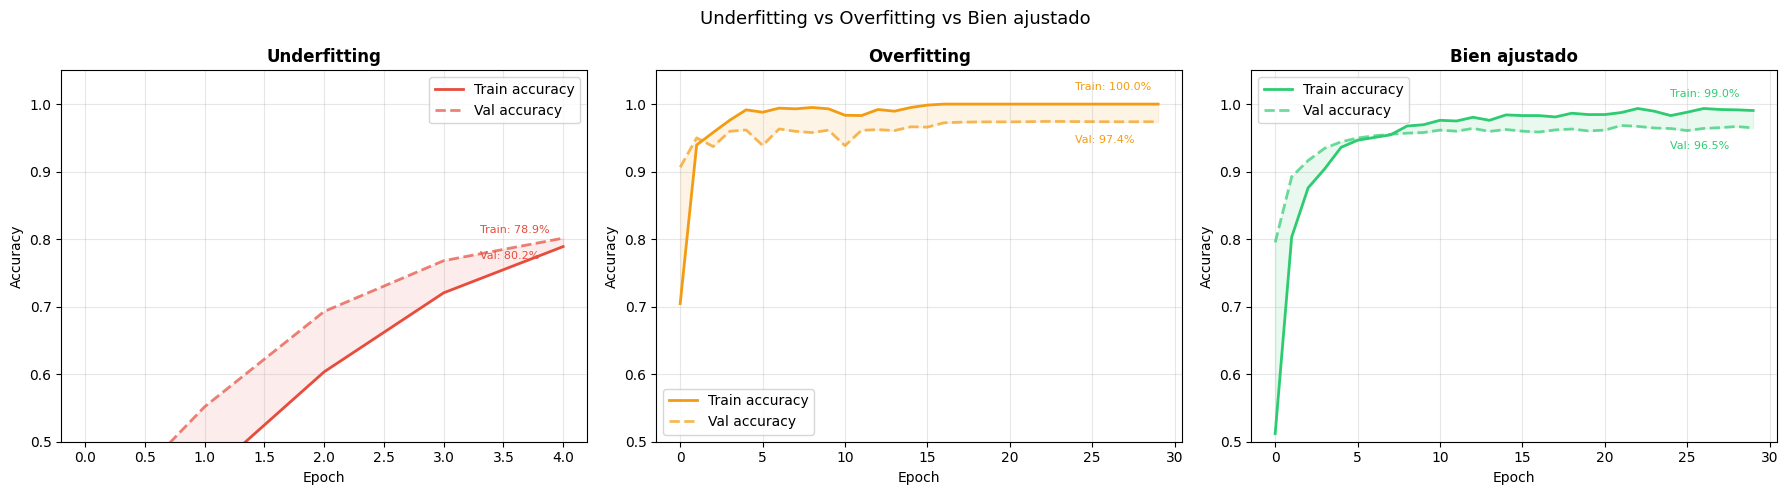

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Underfitting vs Overfitting vs Bien ajustado', fontsize=13)

configuraciones = [
    ('Underfitting',   history_underfit, '#e74c3c'),
    ('Overfitting',    history_overfit,  '#f39c12'),
    ('Bien ajustado',  history_good,     '#2ecc71'),
]

for ax, (nombre, history, color) in zip(axes, configuraciones):
    train_acc = history.history['accuracy']
    val_acc   = history.history['val_accuracy']

    ax.plot(train_acc, label='Train accuracy', linewidth=2, color=color)
    ax.plot(val_acc,   label='Val accuracy',   linewidth=2, color=color,
            linestyle='--', alpha=0.7)

    # Sombrear la brecha entre train y val
    epochs = range(len(train_acc))
    ax.fill_between(epochs, train_acc, val_acc, alpha=0.1, color=color)

    ax.set_title(nombre, fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_ylim(0.5, 1.05)

    # Anotar valores finales
    ax.annotate(f'Train: {train_acc[-1]*100:.1f}%',
                xy=(len(train_acc)-1, train_acc[-1]),
                xytext=(-60, 10), textcoords='offset points',
                fontsize=8, color=color)
    ax.annotate(f'Val: {val_acc[-1]*100:.1f}%',
                xy=(len(val_acc)-1, val_acc[-1]),
                xytext=(-60, -15), textcoords='offset points',
                fontsize=8, color=color)

plt.tight_layout()
plt.savefig('../figures/07_tres_escenarios.png', dpi=120, bbox_inches='tight')
plt.show()

In [14]:
"""
## 6. Early Stopping
Early Stopping es un callback que detiene el entrenamiento
automáticamente cuando la val loss deja de mejorar.
### ¿Por qué es útil?
- Evita el overfitting por entrenamiento excesivo
- Ahorra tiempo — no hace falta definir el número exacto de epochs
- "restore_best_weights=True" recupera los pesos del mejor momento
### Parámetros clave
| Parámetro | Descripción | Valor típico |
|---|---|---|
| "monitor" | Métrica a monitorear | "val_loss" |
| "patience" | Epochs a esperar sin mejora | 5-10 |
| "restore_best_weights" | Recuperar mejores pesos | "True" |
| "min_delta" | Mejora mínima para contar | 0.001 |
### Nota sobre Keras 3
En Keras 3 "restore_best_weights=True" puede tener comportamiento
inesperado combinado con "BatchNormalization" en modelos secuenciales.
Si experimentás val_accuracy cercana al azar después del entrenamiento,
desactivá "restore_best_weights" y guardá el modelo manualmente
en el mejor epoch usando "ModelCheckpoint".
"""

'\n## 6. Early Stopping\nEarly Stopping es un callback que detiene el entrenamiento\nautomáticamente cuando la val loss deja de mejorar.\n### ¿Por qué es útil?\n- Evita el overfitting por entrenamiento excesivo\n- Ahorra tiempo — no hace falta definir el número exacto de epochs\n- "restore_best_weights=True" recupera los pesos del mejor momento\n### Parámetros clave\n| Parámetro | Descripción | Valor típico |\n|---|---|---|\n| "monitor" | Métrica a monitorear | "val_loss" |\n| "patience" | Epochs a esperar sin mejora | 5-10 |\n| "restore_best_weights" | Recuperar mejores pesos | "True" |\n| "min_delta" | Mejora mínima para contar | 0.001 |\n### Nota sobre Keras 3\nEn Keras 3 "restore_best_weights=True" puede tener comportamiento\ninesperado combinado con "BatchNormalization" en modelos secuenciales.\nSi experimentás val_accuracy cercana al azar después del entrenamiento,\ndesactivá "restore_best_weights" y guardá el modelo manualmente\nen el mejor epoch usando "ModelCheckpoint".\n'

In [15]:
# Early stopping correcto en Keras 3
# Usamos ModelCheckpoint para guardar el mejor modelo
# en vez de restore_best_weights=True

model_es = build_good_model()
model_es.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=False,  # Desactivado por bug en Keras 3
    verbose=1
)

model_checkpoint = keras.callbacks.ModelCheckpoint(
    filepath='../models/07_best_model.keras',
    monitor='val_loss',
    save_best_only=True,         # Solo guarda cuando mejora
    verbose=1
)

print("Entrenando con Early Stopping + ModelCheckpoint...")
history_es = model_es.fit(
    X_train_small, y_train_small,
    epochs=50,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping, model_checkpoint],
    verbose=0
)

epochs_ran = len(history_es.history['accuracy'])
print(f"\nEpochs ejecutadas: {epochs_ran}/50")

# Cargar el mejor modelo guardado
best_model = keras.models.load_model('../models/07_best_model.keras')
loss, acc  = best_model.evaluate(X_test, y_test, verbose=0)
print(f"Mejor modelo — Test Accuracy: {acc*100:.1f}%")

Entrenando con Early Stopping + ModelCheckpoint...

Epoch 1: val_loss improved from None to 0.62539, saving model to ../models/07_best_model.keras

Epoch 1: finished saving model to ../models/07_best_model.keras

Epoch 2: val_loss improved from 0.62539 to 0.34836, saving model to ../models/07_best_model.keras

Epoch 2: finished saving model to ../models/07_best_model.keras

Epoch 3: val_loss improved from 0.34836 to 0.26118, saving model to ../models/07_best_model.keras

Epoch 3: finished saving model to ../models/07_best_model.keras

Epoch 4: val_loss improved from 0.26118 to 0.21949, saving model to ../models/07_best_model.keras

Epoch 4: finished saving model to ../models/07_best_model.keras

Epoch 5: val_loss improved from 0.21949 to 0.19136, saving model to ../models/07_best_model.keras

Epoch 5: finished saving model to ../models/07_best_model.keras

Epoch 6: val_loss improved from 0.19136 to 0.15506, saving model to ../models/07_best_model.keras

Epoch 6: finished saving model t

In [16]:
"""
## 7. Guía de diagnóstico y soluciones

### ¿Cómo identificar el problema?
| Síntoma | Diagnóstico | Solución |
|---|---|---|
| Train y val bajas y cercanas | Underfitting | Más capas, más filtros, más epochs |
| Train alta, val baja, brecha grande | Overfitting | Dropout, BN, augmentation, menos params |
| Val loss sube mientras train baja | Overfitting severo | Early stopping, más datos |
| Curvas muy ruidosas | Learning rate alto | Reducir LR o usar scheduler |
| No converge después de muchas epochs | LR muy bajo o bug | Revisar preprocesamiento y LR |
### Checklist para un modelo bien ajustado
- [ ] Arquitectura apropiada para el tamaño del dataset
- [ ] Normalización de los datos
- [ ] Dropout después de capas densas
- [ ] Batch Normalization después de capas convolucionales
- [ ] Data augmentation si el dataset es pequeño
- [ ] Early stopping + ModelCheckpoint
- [ ] Evaluar siempre sobre test set separado
"""

'\n## 7. Guía de diagnóstico y soluciones\n\n### ¿Cómo identificar el problema?\n| Síntoma | Diagnóstico | Solución |\n|---|---|---|\n| Train y val bajas y cercanas | Underfitting | Más capas, más filtros, más epochs |\n| Train alta, val baja, brecha grande | Overfitting | Dropout, BN, augmentation, menos params |\n| Val loss sube mientras train baja | Overfitting severo | Early stopping, más datos |\n| Curvas muy ruidosas | Learning rate alto | Reducir LR o usar scheduler |\n| No converge después de muchas epochs | LR muy bajo o bug | Revisar preprocesamiento y LR |\n### Checklist para un modelo bien ajustado\n- [ ] Arquitectura apropiada para el tamaño del dataset\n- [ ] Normalización de los datos\n- [ ] Dropout después de capas densas\n- [ ] Batch Normalization después de capas convolucionales\n- [ ] Data augmentation si el dataset es pequeño\n- [ ] Early stopping + ModelCheckpoint\n- [ ] Evaluar siempre sobre test set separado\n'